<a href="https://colab.research.google.com/github/slyofzero/BlocksWorldSolver/blob/main/BlocksWorld.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setting up the Blocks World Environment
We are aiming to train a neural network to act as a single-armed robot that can solve a Blocks World problem. For this setting we will have a set of 5 blocks $B = \{A, B, C, D, E\}$ with the goal state being the state where these blocks are stacked in a descending order.


## Predicates -
1. Each block can either be on top of any of the other block (`on(x,y)`) or on the table (`onTable(x)`). Thus 5 predicates per block. Thus in total $5 \times 4 + 5 = \boxed{25}$ predicates to denote the block's position.
2. Each of the blocks can either have some block on top of it or not. This can be denoted using a predicate like `clear(x)` $\forall x \in B$. Thus resulting in $\boxed{5}$ predicates.
3. The robot arm can either be empty or not, we can denote both states using a single predicate `armempty`. Thus $\boxed{1}$ more predicate.
4. If the robot arm is not empty, it must be holding a block. This requires new predicates `holding(x)` $\forall x \in B$. Thus resulting in $\boxed{5}$ predicates.

$$
\text{Total No. of Predicates} = 20 + 5 + 5 + 5 + 1 = 36
$$

## Actions -
1. `stack(x,y)` $\text{s.t} \ x \in B, y \in B-\{x\}$ can be used to stack a block `x` on top of some block `y`. This can have $\boxed{20}$ different permutations.
2. Similarly, `unstack(x,y)` $\text{s.t} \ x \in B, y \in B-\{x\}$ can be used to unstack a block `x` on top of some block `y` and will have also have $\boxed{20}$ permutations.
3. `pickup(x)` $\text{s.t} \ x \in B$ can be used to pick up any block from the table. This will have $\boxed{5}$ possible permutations.
4. Similarly, `putdown(x)` $\text{s.t} \ x \in B$ can be used to put any block on the table and will also have $\boxed{5}$ permutations.

$$
\text{Total No. of Actions} = 20 + 20 + 5 + 5 = 50
$$

# Actions Pre-conditions and Post-effect

1. `unstack(x,y)` -
    - Preconditions - `armempty`, `clear(x)`, `on(x,y)`
    - Add-Effects - `holding(x)`, `clear(y)`
    - Delete-Effects -`armempty`, `on(x,y)`, `clear(x)`

2. `stack(x,y)` -
    - Preconditions - `holding(x)`, `clear(y)`
    - Add-Effects -`on(x,y)`, `armempty`, `clear(x)`
    - Delete-Effects -`holding(x)`, `clear(y)`

3. `pickup(x)` -
    - Preconditions - `armempty`, `clear(x)`, `onTable(x)`
    - Add-Effects - `holding(x)`
    - Delete-Effects - `armempty`, `onTable(x)`, `clear(x)`

4. `putdown(x)` -
    - Preconditions - `holding(x)`
    - Add-Effects - `onTable(x)`, `armempty`, `clear(x)`
    - Delete-Effects - `holding(x)`

In [10]:
from itertools import combinations
import random

import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim

from tqdm.auto import tqdm


In [11]:
class StateGenerator:
  def __init__(self, blocks):
    self.blocks = blocks

  def convert_to_raw_state(self, piles, held=None):
    for pile in piles:
      if len(pile) == 0:
        raise ValueError("State pile cannot be empty.")
      else:
        for block in pile:
          if type(block) != str:
            raise ValueError("Block in piles must be string.")

    return piles, held

  def partition(self, k=2, hold=False):
    blocks = random.sample(self.blocks, k=len(self.blocks))
    held_block = None

    if hold:
      held_block = blocks.pop()
      k -= 1

    n = len(blocks)

    if not (1 <= k <= n):
      lower_limit = 2 if hold else 1
      upper_limit = len(self.blocks)
      input_k     = k+1 if hold else k

      raise ValueError(f"k must be between {lower_limit} and {upper_limit}, got {input_k}")

    cuts = sorted(random.sample(range(1, n), k - 1))
    cuts = [0] + cuts + [n]
    piles = [blocks[cuts[i]:cuts[i + 1]] for i in range(k)]

    return piles, held_block



In [12]:
class BlocksWorldEnv:
  def __init__(
      self,
      block_names: list[str],
      goal_piles: list[list[str]],
      goal_held : str
    ):
    self.blocks = block_names
    self.state_generator = StateGenerator(self.blocks)

    # Making the predicates
    self.predicates = self._init_predicates()
    self.predicates_lookup = {pred: idx for idx, pred in enumerate(self.predicates)}

    # Making the actions
    self.actions = []
    self.action_precond: list[set[int]] = []
    self.action_add    : list[set[int]] = []
    self.action_del    : list[set[int]] = []
    self._init_actions()

    self.actions_lookup = {action: idx for idx, action in enumerate(self.actions)}

    # Goal state of the configuration
    raw_goal_state  = self.state_generator.convert_to_raw_state(goal_piles, goal_held)
    self.goal_state = self.convert_raw_to_predicates(raw_goal_state)
    self.goal_state = self.convert_predicates_to_state(self.goal_state)
    self.goal_piles = goal_piles
    self.goal_held  = goal_held

    # Set current state of the environment
    self.initial_state = None
    self.state         = None
    self.exploration_actions       = []
    self.reset() # sets the initial state and the current state

  # ============================== For Predicates ==============================
  def _init_predicates(self):
    predicates = []

    # All on(x,y) predicates
    for x in self.blocks:
      for y in self.blocks:
        if x == y:
          continue

        predicate = f"on({x},{y})"
        predicates.append(predicate)

    # All onTable(x) predicates
    for x in self.blocks:
      predicate = f"onTable({x})"
      predicates.append(predicate)

    # All clear(x) predicates
    for x in self.blocks:
      predicate = f"clear({x})"
      predicates.append(predicate)

    # armempty predicate
    predicates.append("armempty")

    # All holding(x) predicates
    for x in self.blocks:
      predicate = f"holding({x})"
      predicates.append(predicate)

    return predicates

  # ============================== For Actions ==============================
  def _register_action(self, op_type, x, y = None):
    if op_type == "stack":
        name = f"stack({x},{y})"
        preconds = [f"holding({x})", f"clear({y})"]
        adds = [f"on({x},{y})", "armempty", f"clear({x})"]
        dels = [f"holding({x})", f"clear({y})"]

    elif op_type == "unstack":
        name = f"unstack({x},{y})"
        preconds = ["armempty", f"clear({x})", f"on({x},{y})"]
        adds = [f"holding({x})", f"clear({y})"]
        dels = ["armempty", f"on({x},{y})", f"clear({x})"]

    elif op_type == "pickup":
        name = f"pickup({x})"
        preconds = ["armempty", f"clear({x})", f"onTable({x})"]
        adds = [f"holding({x})"]
        dels = ["armempty", f"onTable({x})", f"clear({x})"]

    elif op_type == "putdown":
        name = f"putdown({x})"
        preconds = [f"holding({x})"]
        adds = [f"onTable({x})", "armempty", f"clear({x})"]
        dels = [f"holding({x})"]

    else:
        raise ValueError(f"Unknown action type: {op_type}")

    # Append the action name and map predicate strings to index sets
    self.actions.append(name)
    self.action_precond.append({self.predicates_lookup[p] for p in preconds})
    self.action_add.append({self.predicates_lookup[p] for p in adds})
    self.action_del.append({self.predicates_lookup[p] for p in dels})

  def _init_actions(self):
    # All stack(x) actions
    for x in self.blocks:
      for y in self.blocks:
        if x == y:
          continue

        self._register_action("stack", x, y)

    # All unstack(x) actions
    for x in self.blocks:
      for y in self.blocks:
        if x == y:
          continue

        self._register_action("unstack", x, y)

    # All pickup(x) actions
    for x in self.blocks:
      self._register_action("pickup", x)

    # All putdown(x) actions
    for x in self.blocks:
      self._register_action("putdown", x)

  # ============================== For Initial State Generation ==============================
  def convert_raw_to_predicates(self, raw_state):
    block_piles, held_block = raw_state
    state = set()

    if held_block:
      state.add(f"holding({held_block})")
    else:
      state.add("armempty")

    for pile in block_piles:
      bottom_block = pile[0]
      top_block    = pile[-1]

      state.add(f"onTable({bottom_block})")
      state.add(f"clear({top_block})")

      if len(pile) > 1:
        for idx in range(1,len(pile)):
          x = pile[idx]
          y = pile[idx-1]
          state.add(f"on({x},{y})")

    return state

  def convert_predicates_to_state(self, state):
    state = {self.predicates_lookup[p] for p in state}
    return state

  def convert_state_to_predicates(self, state):
    state = {self.predicates[id] for id in state}
    return state

  def convert_state_to_vector(self, state=None):
    if state is None:
      state = self.state

    output = torch.zeros(len(self.predicates))
    output[list(state)] = 1
    return output

  def generate_initial_state(self, hold=False):
    n = len(self.blocks)
    p_low = 0.1

    if not hold:
        k_values = list(range(1, n + 1))
        if n <= 2:
            weights = [1.0 / n] * n
        else:
            mid_weight = (1.0 - 2 * p_low) / (n - 2)
            weights = [p_low] + [mid_weight] * (n - 2) + [p_low]
    else:
        k_values = list(range(2, n + 1))
        if n <= 2:
            weights = [1.0]
        else:
            mid_weight = (1.0 - p_low) / (n - 2)
            weights = [mid_weight] * (n - 2) + [p_low]

    k = random.choices(k_values, weights)[0]

    raw_state = self.state_generator.partition(k=k, hold=hold)
    state     = self.convert_raw_to_predicates(raw_state)
    state     = self.convert_predicates_to_state(state)
    return state

  # ============================== For State Transition ==============================
  def get_eligible_actions(self, state=None):
    if state is None:
      state = self.state

    eligible_actions = []

    for action_id, action_precondition in enumerate(self.action_precond):
      if action_precondition.issubset(state):
        eligible_actions.append(action_id)

    return eligible_actions

  def is_action_eligible(self, state, action):
    action_precondition = self.action_precond[action]
    return action_precondition.issubset(state)

  def convert_actions_to_vector(self, actions):
    output = torch.zeros(len(self.actions))
    output[list(actions)] = 1
    return output

  def get_eligible_action_mask(self, state=None):
    eligible_actions = self.get_eligible_actions()
    return self.convert_actions_to_vector(eligible_actions)

  def take_step(self, action):
    if not self.is_action_eligible(self.state, action):
      raise ValueError(f"Action {action} is not eligible for the state {self.state}")

    add_effect: set[int] = self.action_add[action]
    del_effect: set[int] = self.action_del[action]

    self.state = self.state.difference(del_effect).union(add_effect)
    self.exploration_actions.append(action)
    return self.state

  def reset(self):
    self.exploration_actions = []

    while True:
      hold_block = random.random() > 0.7
      self.initial_state = self.generate_initial_state(hold_block)
      self.state = self.initial_state

      if not self.is_goal_reached():
        break

    return self.state

  def is_goal_reached(self):
    return self.state == self.goal_state



# Reward Modelling

1. Predicates in the goal state occur in a similar sequence (partial too) in the current state - $\boxed{+10}$
2. Predicates in the goal state occur but not in a similar sequence (partial too) - $\boxed{-5}$
3. Predicates not in the goal state occur in the current state - $\boxed{-12}$

In [13]:
class RewardModel(BlocksWorldEnv):
  def __init__(
      self,
      block_names: list[str],
      goal_piles: list[list[str]],
      goal_held : str
  ):
    super().__init__(block_names, goal_piles, goal_held)

    self.reset()

  def compute_state_score(self, state=None):
    if state is None:
      state = self.state

    score = 0.0
    INPLACE_REWARD = 2.0  # Kept moderate to prevent gradient explosion

    # 1. Arm condition
    if self.goal_held:
      target_arm = self.predicates_lookup.get(f"holding({self.goal_held})")
    else:
      target_arm = self.predicates_lookup.get("armempty")

    if target_arm in state:
      score += INPLACE_REWARD

    # 2. Grounded pile evaluation (bottom-up)
    for pile in self.goal_piles:
      bottom = pile[0]
      bottom_pred = self.predicates_lookup.get(f"onTable({bottom})")

      # If base is missing, the foundation is invalid; skip this pile
      if bottom_pred not in state:
        continue

      score += INPLACE_REWARD

      # Check stacked blocks sequentially
      pile_intact = True
      for idx in range(1, len(pile)):
        on_pred = self.predicates_lookup.get(f"on({pile[idx]},{pile[idx-1]})")
        if on_pred in state:
          score += INPLACE_REWARD
        else:
          pile_intact = False
          break  # Stop checking this pile if a link is missing

      # If the entire stack is correct, check if the top block is clear
      if pile_intact:
        top = pile[-1]
        clear_pred = self.predicates_lookup.get(f"clear({top})")
        goal_clear_pred = self.predicates_lookup.get(f"clear({top})")
        if goal_clear_pred in self.goal_state and clear_pred in state:
          score += INPLACE_REWARD

    return score

  def calculate_step_reward(self, prev_state, next_state, done):
    STEP_PENALTY = 0.05
    GOAL_BONUS = 50.0

    phi_prev = self.compute_state_score(prev_state)
    phi_next = self.compute_state_score(next_state)

    step_reward = (phi_next - phi_prev) - STEP_PENALTY

    if done:
      step_reward += GOAL_BONUS

    return step_reward

  def take_step(self, action):
    prev_state = self.state.copy()

    super().take_step(action)

    done   = self.is_goal_reached()
    reward = self.calculate_step_reward(prev_state, self.state, done)
    return self.state, reward, done

  def reset(self):
    super().reset()
    return self.state



In [14]:
blocks     = ["A", "B", "C", "D", "E"]
goal_piles = [["E", "D", "C", "B", "A"]]
goal_held  = None

env = RewardModel(blocks, goal_piles, goal_held)

# Neural Network

The neural network would be acting as a policy in this planning problem. This network needs to be made aware of both the current state as well as the goal state. So it will be taking a 72-dimensional input vector which will be achieved by concatenating the current state vector and the goal state vector.

Based upon the current state the network is to decide upon one of the actions that can lead towards achieving the goal state. This is very similar to the implementation of neural networks for multi-class classification problems. However, there exists a cavaet here. Not all action in our action set $A$ are valid actions that can be taken from our current state $s_t$. We can go about this two routes -
1. Have the model learn what the valid actions are at the $t^{th}$ timestep and amongst those pick the best action.
2. Through our environmental knowledge, the invalid actions at the $t^{th}$ timestep are masked out similar to Attention Masking. The model then decides which action to make from the remaining valid actions.

Route 1 would be the most ideal, but because having multiple training objectives for a model usually leads to unexpected complexities down the road, Route 2 is more feasible. In a real-world blocks world problem we do not try to unstack any block in the middle of a pile not because it doesn't occur to us but because the environment itself restricts this. The forced masking introduces a similar kind of environmental restriction on the decision making.

In [15]:
class PolicyNet(nn.Module):
  def __init__(self, input_dim, out_dim):
    super().__init__()
    self.env = env
    self.nn = nn.Sequential(
        nn.Linear(input_dim, 2 * input_dim),
        nn.ReLU(),
        nn.Linear(2 * input_dim, 4 * input_dim),
        nn.ReLU(),
        nn.Linear(4 * input_dim, 2 * input_dim),
        nn.ReLU(),
        nn.Linear(2 * input_dim, out_dim),
    )

  def forward(self, x, mask=None):
    x = self.nn(x)
    if mask is not None:
      x = x.masked_fill(~mask.bool(), -1e9)
    return x



# REINFORCE

For the first policy optimization strategy I'd be using REINFORCE.

In [16]:
# blocks = ["A", "B", "C"]
# goal   = ["C", "B", "A"]
blocks     = ["A", "B", "C", "D", "E"]
goal_piles = [["E", "D", "C", "B", "A"]]
goal_held  = None

env = RewardModel(blocks, goal_piles, goal_held)
lr     = 3e-4

print("========== Goal State Predicates: ==========")
for predicate in env.convert_state_to_predicates(env.state):
  print(predicate)

print()

input_dim = 2 * len(env.predicates)
out_dim   = len(env.actions)

device     = "cuda" if torch.cuda.is_available() else "cpu"
policy_net = PolicyNet(input_dim, out_dim).to(device)
optimizer  = optim.AdamW(policy_net.parameters(), lr=lr)

========== Goal State Predicates: ==========
on(E,A)
onTable(A)
clear(E)
armempty
clear(B)
onTable(D)
onTable(C)
clear(D)
on(B,C)



In [17]:
trajectories_count = 10000
discount = 0.9
max_trajectory_length = 50
batch_size = 16
entropy_coef = 0.01  # Prevents entropy from collapsing below ~0.3
epochs = int(np.ceil(trajectories_count / batch_size))

# Diagnostic storage: appends per-trajectory so history maintains ~3,000 entries
history = {
  "total_rewards": [],
  "episode_lengths": [],
  "successes": [],
  "losses": [],
  "mean_entropies": [],
  "grad_norms": [],
  "final_matches": [],
}

p_bar = tqdm(range(epochs))

for epoch in p_bar:
  p_bar.set_description(f"Epoch {epoch + 1}/{epochs}")

  batch_log_probs = []
  batch_returns = []
  batch_entropies = []

  # Temporary accumulators to capture data from all 16 trajectories
  batch_rewards_list = []
  batch_lengths_list = []
  batch_successes_list = []
  batch_matches_list = []

  # 1. Collect rollouts across the batch
  for b in range(batch_size):
    env.reset()

    ep_rewards = []
    ep_log_probs = []
    ep_entropies = []

    for t in range(max_trajectory_length):
      curr_state_vec = env.convert_state_to_vector(env.state)
      goal_state_vec = env.convert_state_to_vector(env.goal_state)

      input_vec = torch.concat([curr_state_vec, goal_state_vec]).to(device)
      mask = env.get_eligible_action_mask().to(device)

      masked_logits = policy_net(input_vec, mask=mask)
      dist = torch.distributions.Categorical(logits=masked_logits)
      action = dist.sample()

      state, reward, done = env.take_step(action.item())

      ep_rewards.append(reward)
      ep_log_probs.append(dist.log_prob(action))
      ep_entropies.append(dist.entropy())

      if done:
          break

    # Compute discounted returns for this specific trajectory
    R_t = 0.0
    ep_returns = []
    for r in reversed(ep_rewards):
      R_t = r + discount * R_t
      ep_returns.insert(0, R_t)

    batch_log_probs.extend(ep_log_probs)
    batch_returns.extend(ep_returns)
    batch_entropies.extend(ep_entropies)

    # Store individual trajectory metrics
    batch_rewards_list.append(sum(ep_rewards))
    batch_lengths_list.append(len(ep_rewards))
    batch_successes_list.append(1 if done else 0)
    batch_matches_list.append(len(env.state.intersection(env.goal_state)))

  # 2. Batch-level tensors and Advantage standardization
  returns_tensor = torch.tensor(batch_returns, dtype=torch.float32, device=device)
  log_probs_tensor = torch.stack(batch_log_probs)
  entropies_tensor = torch.stack(batch_entropies)

  # Standardize returns across the batch (mean = 0, std = 1)
  if len(returns_tensor) > 1:
    advantages = (returns_tensor - returns_tensor.mean()) / (returns_tensor.std() + 1e-8)
  else:
    advantages = returns_tensor

  # 3. Policy loss with Entropy Regularization
  policy_loss = -(log_probs_tensor * advantages).mean()
  entropy_loss = -entropy_coef * entropies_tensor.mean()
  total_loss = policy_loss + entropy_loss

  # 4. Backward pass and optimizer step
  optimizer.zero_grad()
  total_loss.backward()
  grad_norm = torch.nn.utils.clip_grad_norm_(policy_net.parameters(), max_norm=1.0).item()
  optimizer.step()

  # 5. Record all 16 trajectories into history (preserves your moving-average window scale)
  mean_batch_entropy = entropies_tensor.mean().item()
  for i in range(batch_size):
    history["total_rewards"].append(batch_rewards_list[i])
    history["episode_lengths"].append(batch_lengths_list[i])
    history["successes"].append(batch_successes_list[i])
    history["final_matches"].append(batch_matches_list[i])
    history["losses"].append(total_loss.item())
    history["mean_entropies"].append(mean_batch_entropy)
    history["grad_norms"].append(grad_norm)

  # 6. Real-time batch performance readout
  pct = ((epoch + 1) / epochs) * 100
  p_bar.set_postfix({
    "pct": f"{pct:.1f}%",
    "ret": f"{np.mean(batch_rewards_list):.2f}",
    "succ%": f"{np.mean(batch_successes_list) * 100:.1f}%",
    "steps": f"{np.mean(batch_lengths_list):.1f}",
    "ent": f"{mean_batch_entropy:.2f}",
    "gnorm": f"{grad_norm:.2f}"
  })

  0%|          | 0/625 [00:00<?, ?it/s]

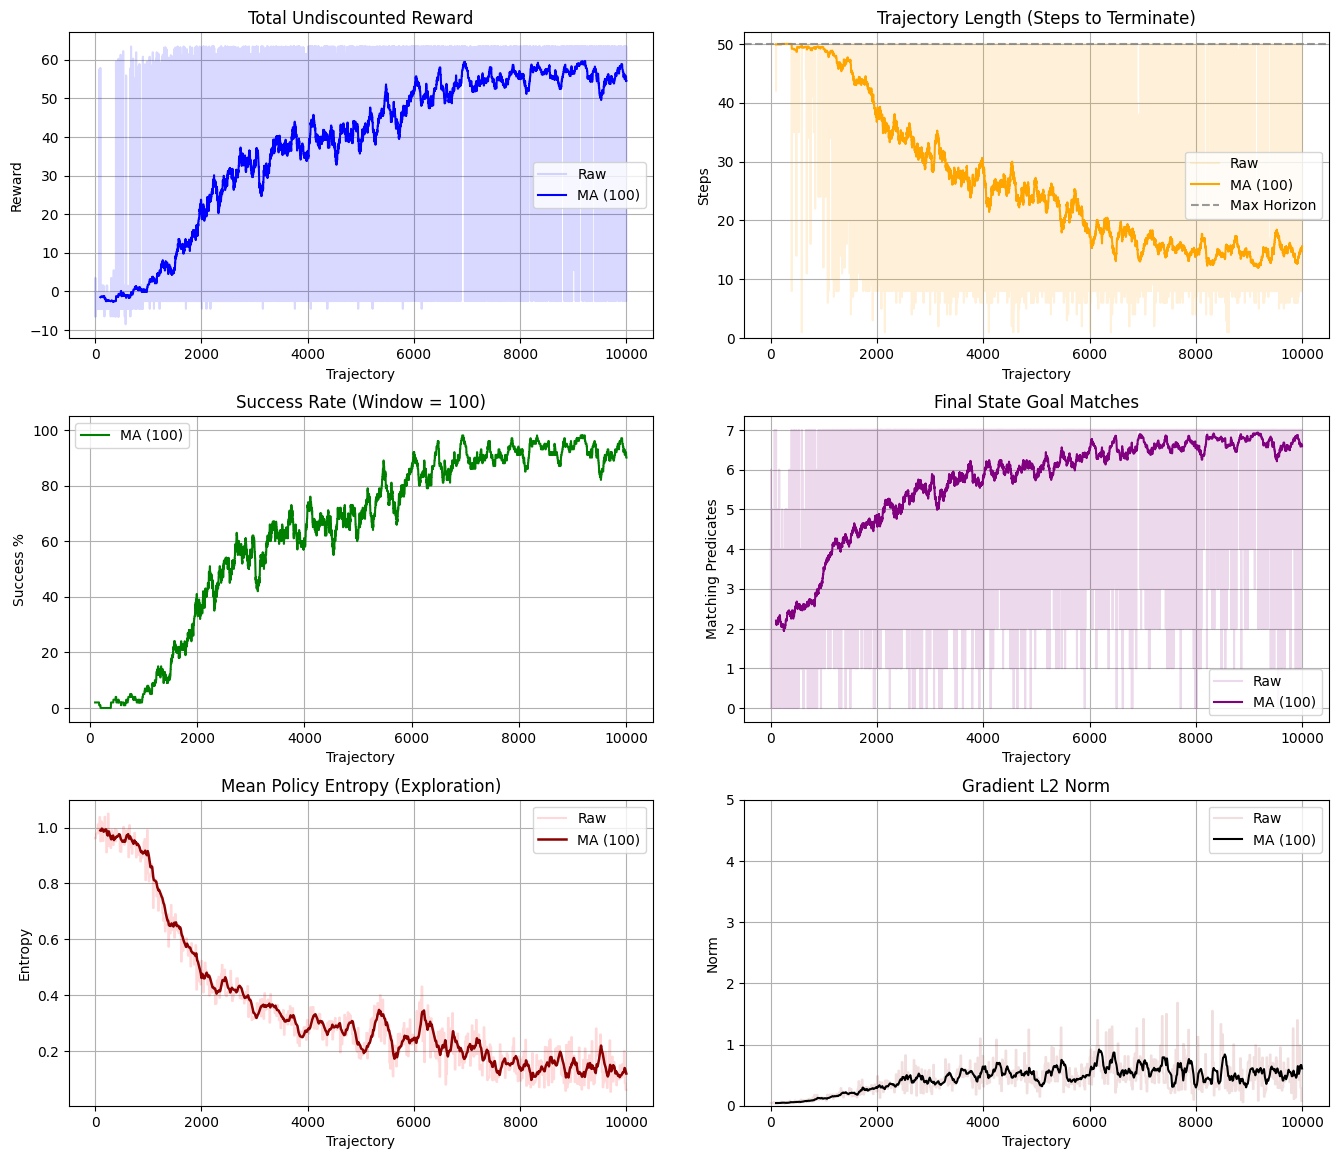

In [18]:
def plot_training_diagnostics(
  history, max_trajectory_length=None, window=None, x_label="Trajectory"
):
    total_points = len(history["total_rewards"])
    if total_points == 0:
        print("History is empty. Nothing to plot.")
        return

    # Scale smoothing window to ~5% of run length (clamped between 2 and 100)
    if window is None:
        window = max(2, min(100, total_points // 20))
    else:
        window = max(1, min(window, total_points))

    # Low alpha for dense runs so raw noise doesn't obscure moving averages
    raw_alpha = 0.35 if total_points < 1000 else 0.15

    def rolling_mean(data, w):
        if len(data) < w or w <= 1:
            return np.array(data)
        return np.convolve(data, np.ones(w) / w, mode="valid")

    x_range = range(1, total_points + 1)
    ma_x = (
        range(window, total_points + 1)
        if total_points >= window and window > 1
        else []
    )

    fig, axs = plt.subplots(3, 2, figsize=(14, 12))
    fig.tight_layout(pad=3.5)

    # 1. Total Undiscounted Reward
    axs[0, 0].plot(
        x_range,
        history["total_rewards"],
        alpha=raw_alpha,
        color="blue",
        label="Raw",
    )
    if len(ma_x) > 0:
        axs[0, 0].plot(
            ma_x,
            rolling_mean(history["total_rewards"], window),
            color="blue",
            label=f"MA ({window})",
        )
    axs[0, 0].set_title("Total Undiscounted Reward")
    axs[0, 0].set_xlabel(x_label)
    axs[0, 0].set_ylabel("Reward")
    axs[0, 0].grid(True)
    axs[0, 0].legend()

    # 2. Episode Length / Steps to Terminate
    axs[0, 1].plot(
        x_range,
        history["episode_lengths"],
        alpha=raw_alpha,
        color="orange",
        label="Raw",
    )
    if len(ma_x) > 0:
        axs[0, 1].plot(
            ma_x,
            rolling_mean(history["episode_lengths"], window),
            color="orange",
            label=f"MA ({window})",
        )
    if max_trajectory_length is not None:
        axs[0, 1].axhline(
            max_trajectory_length,
            color="gray",
            linestyle="--",
            linewidth=1.5,
            alpha=0.8,
            label="Max Horizon",
        )
        axs[0, 1].set_ylim(0, max_trajectory_length + 2)
    axs[0, 1].set_title("Trajectory Length (Steps to Terminate)")
    axs[0, 1].set_xlabel(x_label)
    axs[0, 1].set_ylabel("Steps")
    axs[0, 1].grid(True)
    axs[0, 1].legend()

    # 3. Rolling Success Rate
    if len(ma_x) > 0:
        success_smooth = rolling_mean(history["successes"], window) * 100
        axs[1, 0].plot(
            ma_x, success_smooth, color="green", label=f"MA ({window})"
        )
    else:
        axs[1, 0].plot(
            x_range,
            np.array(history["successes"]) * 100,
            color="green",
            label="Raw %",
        )
    axs[1, 0].set_title(f"Success Rate (Window = {window})")
    axs[1, 0].set_xlabel(x_label)
    axs[1, 0].set_ylabel("Success %")
    axs[1, 0].set_ylim([-5, 105])
    axs[1, 0].grid(True)
    axs[1, 0].legend()

    # 4. Final Subgoal Predicate Matches
    axs[1, 1].plot(
        x_range,
        history["final_matches"],
        alpha=raw_alpha,
        color="purple",
        label="Raw",
    )
    if len(ma_x) > 0:
        axs[1, 1].plot(
            ma_x,
            rolling_mean(history["final_matches"], window),
            color="purple",
            label=f"MA ({window})",
        )
    axs[1, 1].set_title("Final State Goal Matches")
    axs[1, 1].set_xlabel(x_label)
    axs[1, 1].set_ylabel("Matching Predicates")
    axs[1, 1].yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    axs[1, 1].grid(True)
    axs[1, 1].legend()

    # 5. Mean Policy Entropy (Exploration)
    axs[2, 0].plot(
        x_range,
        history["mean_entropies"],
        color="red",
        alpha=raw_alpha,
        label="Raw",
    )
    if len(ma_x) > 0:
        axs[2, 0].plot(
            ma_x,
            rolling_mean(history["mean_entropies"], window),
            color="darkred",
            linewidth=1.8,
            label=f"MA ({window})",
        )
    axs[2, 0].set_title("Mean Policy Entropy (Exploration)")
    axs[2, 0].set_xlabel(x_label)
    axs[2, 0].set_ylabel("Entropy")
    axs[2, 0].grid(True)
    axs[2, 0].legend()

    # 6. Gradient L2 Norm
    axs[2, 1].plot(
        x_range,
        history["grad_norms"],
        color="brown",
        alpha=raw_alpha,
        label="Raw",
    )
    if len(ma_x) > 0:
        ma_grad = rolling_mean(history["grad_norms"], window)
        axs[2, 1].plot(
            ma_x, ma_grad, color="black", linewidth=1.5, label=f"MA ({window})"
        )

        # Dynamic y-limit: prevent solitary 6,000+ spikes from squashing the MA curve
        upper_limit = np.percentile(history["grad_norms"], 98.5) * 1.5
        axs[2, 1].set_ylim(0, max(upper_limit, np.max(ma_grad) * 1.25, 5.0))

    axs[2, 1].set_title("Gradient L2 Norm")
    axs[2, 1].set_xlabel(x_label)
    axs[2, 1].set_ylabel("Norm")
    axs[2, 1].grid(True)
    axs[2, 1].legend()

    plt.show()

plot_training_diagnostics(
    history=history,
    max_trajectory_length=max_trajectory_length
)



In [29]:
blocks     = ["A", "B", "C", "D", "E"]
goal_piles = [["E", "D", "C", "B", "A"]]
goal_held  = None
env = RewardModel(blocks, goal_piles, goal_held)
steps = 0

for _ in range(50):
  curr_state_vec = env.convert_state_to_vector(env.state)
  goal_state_vec = env.convert_state_to_vector(env.goal_state)

  input_vec = torch.concat([curr_state_vec, goal_state_vec]).to(device)
  mask = env.get_eligible_action_mask().to(device)

  masked_logits = policy_net(input_vec, mask=mask)
  dist = torch.distributions.Categorical(logits=masked_logits)
  action = dist.sample()

  print("State and Action -")
  print(", ".join(env.convert_state_to_predicates(env.state)))
  print(env.actions[action])
  print()

  env.take_step(action)
  steps += 1

  if env.is_goal_reached():
    break

print(f"Reached the goal state in {steps} steps")

State and Action -
on(B,A), clear(E), on(A,C), armempty, on(E,D), onTable(C), on(D,B)
unstack(E,D)

State and Action -
on(B,A), on(A,C), onTable(C), clear(D), holding(E), on(D,B)
putdown(E)

State and Action -
onTable(E), on(B,A), clear(E), on(A,C), armempty, onTable(C), clear(D), on(D,B)
unstack(D,B)

State and Action -
onTable(E), on(B,A), clear(E), on(A,C), clear(B), onTable(C), holding(D)
stack(D,E)

State and Action -
onTable(E), on(B,A), on(A,C), clear(B), armempty, onTable(C), clear(D), on(D,E)
unstack(B,A)

State and Action -
onTable(E), on(A,C), onTable(C), clear(A), clear(D), holding(B), on(D,E)
putdown(B)

State and Action -
onTable(E), on(A,C), clear(B), armempty, onTable(C), clear(A), onTable(B), clear(D), on(D,E)
unstack(A,C)

State and Action -
onTable(E), clear(B), clear(C), onTable(C), clear(D), onTable(B), holding(A), on(D,E)
putdown(A)

State and Action -
onTable(E), onTable(A), armempty, clear(B), clear(C), onTable(C), clear(A), onTable(B), clear(D), on(D,E)
pickup(